# Red Sox offensive performance by season period 2024-2026

## Research Question
Has the Boston Red Sox offense performed better during July and
August than during the beginning and end of the season from 2024–2026?

## Definitions
Early: All regular season games played in the months of March, April, May, and June.
Middle: All regular season games played in the months of July and August.
Late: All regular season games played in the months of September and October.
Wild Card: 2 wild card series games against the New York Yankees in 2026.

## Data and Methodology
All player and team statistics were collected from baseball-reference. Imported into python and reproduced into charts using pandas, numpy, and matplotlib.pyplot. Offensive performance was evaluated using AVG, OBP, SLG, OPS, and runs per game, since the main objective of baseball is to score runs. The Red Sox' performance is also compared to the league's performcance to account for league-wide fluctuations in offensive performance. 

## Data Collection and Preparation
Game-level Red Sox schedule and scoring data were collected using the `pybaseball` package. Monthly team batting splits were obtained from Baseball-Reference. The data were cleaned and divided into Early, Middle, and Late season periods for analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pybaseball import schedule_and_record, batting_stats_range

In [2]:
BOS_2024= schedule_and_record(2024, "BOS")

http://www.baseball-reference.com/teams/BOS/2024-schedule-scores.shtml


/opt/anaconda3/lib/python3.14/site-packages/pybaseball/team_results.py:75: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


In [3]:
BOS_2024["Original_Date"] = BOS_2024["Date"]

BOS_2024["Date"] = BOS_2024["Date"].str.replace(
    r" \(\d+\)", "", regex=True
)

BOS_2024["Date"] = pd.to_datetime(
   BOS_2024["Date"] + " 2024",
    format="%A, %b %d %Y"
)

BOS_2024["Date"].dtype
BOS_2024["Date"].dtype
BOS_2024["Month"]=BOS_2024["Date"].dt.month
#Isolate data by time period
BOS_2024_March_April_May_June = BOS_2024[
    BOS_2024["Month"].isin([3, 4, 5, 6])
]
BOS_2024_July_August=BOS_2024[BOS_2024["Month"].isin([7,8])]
BOS_2024_September=BOS_2024[BOS_2024["Month"]==9]

#Runs per game in each period#
Runspergame_early_2024 = round(
    BOS_2024_March_April_May_June["R"].sum() / len(BOS_2024_March_April_May_June), 2)

Runspergame_middle_2024 = round(
    BOS_2024_July_August["R"].sum() / len(BOS_2024_July_August), 2)

Runspergame_late_2024 = round(
    BOS_2024_September["R"].sum() / len(BOS_2024_September), 2)

RedSox_2024_RPG = {
    "Early": float(Runspergame_early_2024),
    "Middle": float(Runspergame_middle_2024),
    "Late": float(Runspergame_late_2024)}



In [4]:
# Load Baseball-Reference monthly team batting splits
# Early-period batting statistics
BOS_2024_Batting = pd.read_csv("BOS_2024.csv")
BOS_2024_Batting_Early = BOS_2024_Batting[
    BOS_2024_Batting["Split"].isin(["April/March", "May", "June"])]

H = BOS_2024_Batting_Early["H"].sum()
AB = BOS_2024_Batting_Early["AB"].sum()
BB = BOS_2024_Batting_Early["BB"].sum()
HBP = BOS_2024_Batting_Early["HBP"].sum()
SF = BOS_2024_Batting_Early["SF"].sum()
TB = BOS_2024_Batting_Early["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2024_Early_AVG = round(AVG_raw, 3)
BOS_2024_Early_OBP = round(OBP_raw, 3)
BOS_2024_Early_SLG = round(SLG_raw, 3)
BOS_2024_Early_OPS = round(OPS_raw, 3)


In [5]:
#July-Aug AVG, OBP, SLG, OPS, OPS+#
BOS_2024_Batting_Middle = BOS_2024_Batting[
    BOS_2024_Batting["Split"].isin(["July", "August"])]

H = BOS_2024_Batting_Middle["H"].sum()
AB = BOS_2024_Batting_Middle["AB"].sum()
BB = BOS_2024_Batting_Middle["BB"].sum()
HBP = BOS_2024_Batting_Middle["HBP"].sum()
SF = BOS_2024_Batting_Middle["SF"].sum()
TB = BOS_2024_Batting_Middle["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2024_Middle_AVG = round(AVG_raw, 3)
BOS_2024_Middle_OBP = round(OBP_raw, 3)
BOS_2024_Middle_SLG = round(SLG_raw, 3)
BOS_2024_Middle_OPS = round(OPS_raw, 3)

In [6]:
#September AVG, OBP, SLG, OPS, OPS+#
BOS_2024_Batting_Late = BOS_2024_Batting[
    BOS_2024_Batting["Split"] == "Sept/Oct"]

H = BOS_2024_Batting_Late["H"].sum()
AB = BOS_2024_Batting_Late["AB"].sum()
BB = BOS_2024_Batting_Late["BB"].sum()
HBP = BOS_2024_Batting_Late["HBP"].sum()
SF = BOS_2024_Batting_Late["SF"].sum()
TB = BOS_2024_Batting_Late["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2024_Late_AVG = round(AVG_raw, 3)
BOS_2024_Late_OBP = round(OBP_raw, 3)
BOS_2024_Late_SLG = round(SLG_raw, 3)
BOS_2024_Late_OPS = round(OPS_raw, 3)

In [7]:
Red_Sox_Offense_2024={
    "Early": {"AVG": BOS_2024_Early_AVG, 
             "OBP": BOS_2024_Early_OBP, 
             "SLG": BOS_2024_Early_SLG, 
            "OPS": BOS_2024_Early_OPS},

    "Middle": {"AVG": BOS_2024_Middle_AVG, 
                "OBP": BOS_2024_Middle_OBP, 
                "SLG": BOS_2024_Middle_SLG,
                "OPS": BOS_2024_Middle_OPS},

    "Late": {"AVG": BOS_2024_Late_AVG,
            "OBP": BOS_2024_Late_OBP,
            "SLG": BOS_2024_Late_SLG,
            "OPS": BOS_2024_Late_OPS}}


In [8]:
BOS_2025 = schedule_and_record(2025, "BOS")

BOS_2025_Batting = pd.read_csv("BOS_2025.csv")

http://www.baseball-reference.com/teams/BOS/2025-schedule-scores.shtml


/opt/anaconda3/lib/python3.14/site-packages/pybaseball/team_results.py:75: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


In [9]:
# Early-period batting statistics
BOS_2025_Batting_Early = BOS_2025_Batting[
    BOS_2025_Batting["Split"].isin(["April/March", "May", "June"])
]

H = BOS_2025_Batting_Early["H"].sum()
AB = BOS_2025_Batting_Early["AB"].sum()
BB = BOS_2025_Batting_Early["BB"].sum()
HBP = BOS_2025_Batting_Early["HBP"].sum()
SF = BOS_2025_Batting_Early["SF"].sum()
TB = BOS_2025_Batting_Early["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2025_Early_AVG = round(AVG_raw, 3)
BOS_2025_Early_OBP = round(OBP_raw, 3)
BOS_2025_Early_SLG = round(SLG_raw, 3)
BOS_2025_Early_OPS = round(OPS_raw, 3)

In [10]:
# Middle-period batting statistics
BOS_2025_Batting_Middle = BOS_2025_Batting[
    BOS_2025_Batting["Split"].isin(["July", "August"])]

H = BOS_2025_Batting_Middle["H"].sum()
AB = BOS_2025_Batting_Middle["AB"].sum()
BB = BOS_2025_Batting_Middle["BB"].sum()
HBP = BOS_2025_Batting_Middle["HBP"].sum()
SF = BOS_2025_Batting_Middle["SF"].sum()
TB = BOS_2025_Batting_Middle["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2025_Middle_AVG = round(AVG_raw, 3)
BOS_2025_Middle_OBP = round(OBP_raw, 3)
BOS_2025_Middle_SLG = round(SLG_raw, 3)
BOS_2025_Middle_OPS = round(OPS_raw, 3)

In [11]:
# Late-period batting statistics
BOS_2025_Batting_Late = BOS_2025_Batting[
    BOS_2025_Batting["Split"] == "Sept/Oct"
]

H = BOS_2025_Batting_Late["H"].sum()
AB = BOS_2025_Batting_Late["AB"].sum()
BB = BOS_2025_Batting_Late["BB"].sum()
HBP = BOS_2025_Batting_Late["HBP"].sum()
SF = BOS_2025_Batting_Late["SF"].sum()
TB = BOS_2025_Batting_Late["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2025_Late_AVG = round(AVG_raw, 3)
BOS_2025_Late_OBP = round(OBP_raw, 3)
BOS_2025_Late_SLG = round(SLG_raw, 3)
BOS_2025_Late_OPS = round(OPS_raw, 3)

In [12]:
Red_Sox_Offense_2025 = {"Early": {
        "AVG": BOS_2025_Early_AVG,
        "OBP": BOS_2025_Early_OBP,
        "SLG": BOS_2025_Early_SLG,
        "OPS": BOS_2025_Early_OPS},
    "Middle": {
        "AVG": BOS_2025_Middle_AVG,
        "OBP": BOS_2025_Middle_OBP,
        "SLG": BOS_2025_Middle_SLG,
        "OPS": BOS_2025_Middle_OPS},
    "Late": {
        "AVG": BOS_2025_Late_AVG,
        "OBP": BOS_2025_Late_OBP,
        "SLG": BOS_2025_Late_SLG,
        "OPS": BOS_2025_Late_OPS}}

In [13]:
BOS_2025["Original_Date"] = BOS_2025["Date"]

BOS_2025["Date"] = BOS_2025["Date"].str.replace(
    r" \(\d+\)", "", regex=True)
BOS_2025["Date"] = pd.to_datetime(
   BOS_2025["Date"] + " 2025",
    format="%A, %b %d %Y")

BOS_2025["Date"].dtype
BOS_2025["Date"].dtype
BOS_2025["Month"]=BOS_2025["Date"].dt.month
# Isolate games by season period
BOS_2025_March_April_May_June = BOS_2025[
    BOS_2025["Month"].isin([3, 4, 5, 6])]

BOS_2025_July_August = BOS_2025[
    BOS_2025["Month"].isin([7, 8])]

BOS_2025_September = BOS_2025[
    BOS_2025["Month"] == 9]

# Calculate runs per game for each season period
Runspergame_early_2025 = round(
    BOS_2025_March_April_May_June["R"].sum() / len(BOS_2025_March_April_May_June), 2)

Runspergame_middle_2025 = round(
    BOS_2025_July_August["R"].sum() / len(BOS_2025_July_August), 2)

Runspergame_late_2025 = round(
    BOS_2025_September["R"].sum() / len(BOS_2025_September), 2)

RedSox_2025_RPG = {
    "Early": float(Runspergame_early_2025),
    "Middle": float(Runspergame_middle_2025),
    "Late": float(Runspergame_late_2025)}

In [14]:
BOS_2026 = schedule_and_record(2026, "BOS")
BOS_2026_Batting = pd.read_csv("BOS_2026.csv")

http://www.baseball-reference.com/teams/BOS/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.14/site-packages/pybaseball/team_results.py:75: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


In [15]:
# Early-period batting statistics
BOS_2026_Batting_Early = BOS_2026_Batting[
    BOS_2026_Batting["Split"].isin(["April/March", "May", "June"])
]

H = BOS_2026_Batting_Early["H"].sum()
AB = BOS_2026_Batting_Early["AB"].sum()
BB = BOS_2026_Batting_Early["BB"].sum()
HBP = BOS_2026_Batting_Early["HBP"].sum()
SF = BOS_2026_Batting_Early["SF"].sum()
TB = BOS_2026_Batting_Early["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2026_Early_AVG = round(AVG_raw, 3)
BOS_2026_Early_OBP = round(OBP_raw, 3)
BOS_2026_Early_SLG = round(SLG_raw, 3)
BOS_2026_Early_OPS = round(OPS_raw, 3)

In [16]:
# Middle-period batting statistics
BOS_2026_Batting_Middle = BOS_2026_Batting[
    BOS_2026_Batting["Split"].isin(["July", "August"])
]

H = BOS_2026_Batting_Middle["H"].sum()
AB = BOS_2026_Batting_Middle["AB"].sum()
BB = BOS_2026_Batting_Middle["BB"].sum()
HBP = BOS_2026_Batting_Middle["HBP"].sum()
SF = BOS_2026_Batting_Middle["SF"].sum()
TB = BOS_2026_Batting_Middle["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2026_Middle_AVG = round(AVG_raw, 3)
BOS_2026_Middle_OBP = round(OBP_raw, 3)
BOS_2026_Middle_SLG = round(SLG_raw, 3)
BOS_2026_Middle_OPS = round(OPS_raw, 3)

In [17]:
# Late-period batting statistics
BOS_2026_Batting_Late = BOS_2026_Batting[
    BOS_2026_Batting["Split"] == "Sept/Oct"
]

H = BOS_2026_Batting_Late["H"].sum()
AB = BOS_2026_Batting_Late["AB"].sum()
BB = BOS_2026_Batting_Late["BB"].sum()
HBP = BOS_2026_Batting_Late["HBP"].sum()
SF = BOS_2026_Batting_Late["SF"].sum()
TB = BOS_2026_Batting_Late["TB"].sum()

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

BOS_2026_Late_AVG = round(AVG_raw, 3)
BOS_2026_Late_OBP = round(OBP_raw, 3)
BOS_2026_Late_SLG = round(SLG_raw, 3)
BOS_2026_Late_OPS = round(OPS_raw, 3)

In [18]:
Red_Sox_Offense_2026 = {
    "Early": {
        "AVG": BOS_2026_Early_AVG,
        "OBP": BOS_2026_Early_OBP,
        "SLG": BOS_2026_Early_SLG,
        "OPS": BOS_2026_Early_OPS
    },
    "Middle": {
        "AVG": BOS_2026_Middle_AVG,
        "OBP": BOS_2026_Middle_OBP,
        "SLG": BOS_2026_Middle_SLG,
        "OPS": BOS_2026_Middle_OPS
    },
    "Late": {
        "AVG": BOS_2026_Late_AVG,
        "OBP": BOS_2026_Late_OBP,
        "SLG": BOS_2026_Late_SLG,
        "OPS": BOS_2026_Late_OPS}}

In [19]:
BOS_2026= schedule_and_record(2026, "BOS")


http://www.baseball-reference.com/teams/BOS/2026-schedule-scores.shtml


/opt/anaconda3/lib/python3.14/site-packages/pybaseball/team_results.py:75: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Attendance'].replace(r'^Unknown$', np.nan, regex=True, inplace = True) # make this a NaN so the column can benumeric


In [20]:
BOS_2026["Original_Date"] = BOS_2026["Date"]

BOS_2026["Date"] = BOS_2026["Date"].str.replace(
    r" \(\d+\)", "", regex=True
)

BOS_2026["Date"] = pd.to_datetime(
   BOS_2026["Date"] + " 2026",
    format="%A, %b %d %Y"
)

BOS_2026["Date"].dtype
BOS_2026["Date"].dtype
BOS_2026["Month"]=BOS_2026["Date"].dt.month
#Isolate data by time period
BOS_2026_March_April_May_June=BOS_2026[(BOS_2026["Month"]==3) | (BOS_2026["Month"]==4) | (BOS_2026["Month"]==5) | (BOS_2026["Month"]==6)]
BOS_2026_July_August=BOS_2026[BOS_2026["Month"].isin([7,8])]
BOS_2026_September=BOS_2026[BOS_2026["Month"]==9]

#Runs per game in each period#
Runspergame_Apr_May_June_2026=BOS_2026_March_April_May_June["R"].sum()/len(BOS_2026_March_April_May_June)
Runspergame_early=round(Runspergame_Apr_May_June_2026, 2)


Runspergame_July_August_2026=BOS_2026_July_August["R"].sum()/len(BOS_2026_July_August)
Runspergame_middle=round(Runspergame_July_August_2026, 2)


Runspergame_September_2026=BOS_2026_September["R"].sum()/len(BOS_2026_September)
Runspergame_late=round(Runspergame_September_2026, 2)


RedSox_2026_RPG={"Early": float(Runspergame_early), 
                 "Middle": float(Runspergame_middle), 
                 "Late": float(Runspergame_late)}
print(RedSox_2026_RPG)

{'Early': 3.99, 'Middle': 5.24, 'Late': 3.0}


In [21]:
rows = []

for year, offense, rpg in [
    (2024, Red_Sox_Offense_2024, RedSox_2024_RPG),
    (2025, Red_Sox_Offense_2025, RedSox_2025_RPG),
    (2026, Red_Sox_Offense_2026, RedSox_2026_RPG)
]:
    for period in ["Early", "Middle", "Late"]:
        rows.append({
            "Year": year,
            "Period": period,
            "Runs Per Game": rpg[period],
            "AVG": offense[period]["AVG"],
            "OBP": offense[period]["OBP"],
            "SLG": offense[period]["SLG"],
            "OPS": offense[period]["OPS"]
        })

RedSox_Offense_2024_2026 = pd.DataFrame(rows)

## Red Sox Offensive Performance, 2024-2026

In [22]:
RedSox_Offense_2024_2026



,Year,Period,Runs Per Game,AVG,OBP,SLG,OPS
0,2024,Early,4.55,0.251,0.321,0.418,0.739
1,2024,Middle,5.29,0.265,0.325,0.461,0.785
2,2024,Late,3.64,0.224,0.299,0.354,0.654
3,2025,Early,4.79,0.250,0.323,0.421,0.744
4,2025,Middle,5.12,0.256,0.324,0.430,0.753
5,2025,Late,4.52,0.267,0.325,0.406,0.731
6,2026,Early,3.99,0.243,0.310,0.384,0.694
7,2026,Middle,5.24,0.260,0.343,0.437,0.779
8,2026,Late,3.00,0.219,0.295,0.356,0.651


In [23]:
Period_Averages = (
    RedSox_Offense_2024_2026
    .groupby("Period")[["Runs Per Game", "AVG", "OBP", "SLG", "OPS"]]
    .mean()
    .loc[["Early", "Middle", "Late"]]
    .round(3)
)

Period_Averages

,Runs Per Game,AVG,OBP,SLG,OPS
Period,,,,,
Early,4.443,0.248,0.318,0.408,0.726
Middle,5.217,0.260,0.331,0.443,0.772
Late,3.720,0.237,0.306,0.372,0.679


### Results

From 2024–2026, the Red Sox offense performed best during the Middle period (July and August) in each season based on both runs per game and OPS. Boston averaged 5.29 runs per game with a .786 OPS during the Middle period in 2024, 5.12 runs per game with a .754 OPS in 2025, and 5.24 runs per game with a .780 OPS in 2026.

Across all three seasons, the Middle period averaged 5.22 runs per game and a .773 OPS, compared with 4.44 runs per game and a .726 OPS during the Early period and 3.72 runs per game and a .679 OPS during the Late period.

### Comparison to MLB Average

To determine whether the Red Sox's seasonal offensive pattern reflects broader league-wide trends, Boston's performance is compared with MLB-wide offensive statistics over the same Early, Middle, and Late periods.

League statistics are calculated using the same date ranges used for the Red Sox analysis.

In [24]:
MLB_2024_Early = batting_stats_range(
    "2024-03-20",
    "2024-06-30"
)

In [25]:

H = MLB_2024_Early["H"].sum()
AB = MLB_2024_Early["AB"].sum()
BB = MLB_2024_Early["BB"].sum()
HBP = MLB_2024_Early["HBP"].sum()
SF = MLB_2024_Early["SF"].sum()
TB = MLB_2024_Early["H"].sum() + \
     2 * MLB_2024_Early["2B"].sum() + \
     3 * MLB_2024_Early["3B"].sum() + \
     4 * MLB_2024_Early["HR"].sum()

MLB_2024_Early_AVG = round(H / AB, 3)
MLB_2024_Early_OBP = round(
    (H + BB + HBP) / (AB + BB + HBP + SF), 3
)
MLB_2024_Early_SLG = round(TB / AB, 3)

MLB_2024_Early_OPS = round(
    (H + BB + HBP) / (AB + BB + HBP + SF) + (TB / AB),
    3
)

In [26]:

MLB_2024_Middle = batting_stats_range(
    "2024-07-01",
    "2024-08-31"
)

In [27]:

H = MLB_2024_Middle["H"].sum()
AB = MLB_2024_Middle["AB"].sum()
BB = MLB_2024_Middle["BB"].sum()
HBP = MLB_2024_Middle["HBP"].sum()
SF = MLB_2024_Middle["SF"].sum()

TB = (
    MLB_2024_Middle["H"].sum()
    + MLB_2024_Middle["2B"].sum()
    + 2 * MLB_2024_Middle["3B"].sum()
    + 3 * MLB_2024_Middle["HR"].sum()
)

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

MLB_2024_Middle_AVG = round(AVG_raw, 3)
MLB_2024_Middle_OBP = round(OBP_raw, 3)
MLB_2024_Middle_SLG = round(SLG_raw, 3)
MLB_2024_Middle_OPS = round(OPS_raw, 3)

In [28]:
MLB_2024_Late = batting_stats_range(
    "2024-09-01",
    "2024-10-31"
)


In [29]:
# MLB 2024 Late-period batting statistics
H = MLB_2024_Late["H"].sum()
AB = MLB_2024_Late["AB"].sum()
BB = MLB_2024_Late["BB"].sum()
HBP = MLB_2024_Late["HBP"].sum()
SF = MLB_2024_Late["SF"].sum()

TB = (
    MLB_2024_Late["H"].sum()
    + MLB_2024_Late["2B"].sum()
    + 2 * MLB_2024_Late["3B"].sum()
    + 3 * MLB_2024_Late["HR"].sum()
)

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

MLB_2024_Late_AVG = round(AVG_raw, 3)
MLB_2024_Late_OBP = round(OBP_raw, 3)
MLB_2024_Late_SLG = round(SLG_raw, 3)
MLB_2024_Late_OPS = round(OPS_raw, 3)

In [30]:
MLB_Offense_2024 = {
    "Early": {
        "AVG": MLB_2024_Early_AVG,
        "OBP": MLB_2024_Early_OBP,
        "SLG": MLB_2024_Early_SLG,
        "OPS": MLB_2024_Early_OPS
    },
    "Middle": {
        "AVG": MLB_2024_Middle_AVG,
        "OBP": MLB_2024_Middle_OBP,
        "SLG": MLB_2024_Middle_SLG,
        "OPS": MLB_2024_Middle_OPS
    },
    "Late": {
        "AVG": MLB_2024_Late_AVG,
        "OBP": MLB_2024_Late_OBP,
        "SLG": MLB_2024_Late_SLG,
        "OPS": MLB_2024_Late_OPS
    }
}

In [31]:
MLB_2025_Early = batting_stats_range(
    "2025-03-20",
    "2025-06-30"
)


In [32]:
H = MLB_2025_Early["H"].sum()
AB = MLB_2025_Early["AB"].sum()
BB = MLB_2025_Early["BB"].sum()
HBP = MLB_2025_Early["HBP"].sum()
SF = MLB_2025_Early["SF"].sum()

TB = (
    MLB_2025_Early["H"].sum()
    + MLB_2025_Early["2B"].sum()
    + 2 * MLB_2025_Early["3B"].sum()
    + 3 * MLB_2025_Early["HR"].sum()
)

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

MLB_2025_Early_AVG = round(AVG_raw, 3)
MLB_2025_Early_OBP = round(OBP_raw, 3)
MLB_2025_Early_SLG = round(SLG_raw, 3)
MLB_2025_Early_OPS = round(OPS_raw, 3)

In [33]:
MLB_2025_Middle = batting_stats_range(
    "2025-07-01",
    "2025-08-31"
)

In [34]:
H = MLB_2025_Middle["H"].sum()
AB = MLB_2025_Middle["AB"].sum()
BB = MLB_2025_Middle["BB"].sum()
HBP = MLB_2025_Middle["HBP"].sum()
SF = MLB_2025_Middle["SF"].sum()

TB = (
    MLB_2025_Middle["H"].sum()
    + MLB_2025_Middle["2B"].sum()
    + 2 * MLB_2025_Middle["3B"].sum()
    + 3 * MLB_2025_Middle["HR"].sum()
)

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

MLB_2025_Middle_AVG = round(AVG_raw, 3)
MLB_2025_Middle_OBP = round(OBP_raw, 3)
MLB_2025_Middle_SLG = round(SLG_raw, 3)
MLB_2025_Middle_OPS = round(OPS_raw, 3)

In [35]:
MLB_2025_Late = batting_stats_range(
    "2025-09-01",
    "2025-10-31"
)

In [36]:
H = MLB_2025_Late["H"].sum()
AB = MLB_2025_Late["AB"].sum()
BB = MLB_2025_Late["BB"].sum()
HBP = MLB_2025_Late["HBP"].sum()
SF = MLB_2025_Late["SF"].sum()

TB = (
    MLB_2025_Late["H"].sum()
    + MLB_2025_Late["2B"].sum()
    + 2 * MLB_2025_Late["3B"].sum()
    + 3 * MLB_2025_Late["HR"].sum()
)

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

MLB_2025_Late_AVG = round(AVG_raw, 3)
MLB_2025_Late_OBP = round(OBP_raw, 3)
MLB_2025_Late_SLG = round(SLG_raw, 3)
MLB_2025_Late_OPS = round(OPS_raw, 3)

In [37]:
MLB_Offense_2025 = {
    "Early": {
        "AVG": MLB_2025_Early_AVG,
        "OBP": MLB_2025_Early_OBP,
        "SLG": MLB_2025_Early_SLG,
        "OPS": MLB_2025_Early_OPS
    },
    "Middle": {
        "AVG": MLB_2025_Middle_AVG,
        "OBP": MLB_2025_Middle_OBP,
        "SLG": MLB_2025_Middle_SLG,
        "OPS": MLB_2025_Middle_OPS
    },
    "Late": {
        "AVG": MLB_2025_Late_AVG,
        "OBP": MLB_2025_Late_OBP,
        "SLG": MLB_2025_Late_SLG,
        "OPS": MLB_2025_Late_OPS
    }
}

In [38]:
MLB_2026_Early = batting_stats_range(
    "2026-03-20",
    "2026-06-30"
)



In [39]:
H = MLB_2026_Early["H"].sum()
AB = MLB_2026_Early["AB"].sum()
BB = MLB_2026_Early["BB"].sum()
HBP = MLB_2026_Early["HBP"].sum()
SF = MLB_2026_Early["SF"].sum()

TB = (
    MLB_2026_Early["H"].sum()
    + MLB_2026_Early["2B"].sum()
    + 2 * MLB_2026_Early["3B"].sum()
    + 3 * MLB_2026_Early["HR"].sum()
)

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

MLB_2026_Early_AVG = round(AVG_raw, 3)
MLB_2026_Early_OBP = round(OBP_raw, 3)
MLB_2026_Early_SLG = round(SLG_raw, 3)
MLB_2026_Early_OPS = round(OPS_raw, 3)

In [40]:
MLB_2026_Middle = batting_stats_range(
    "2026-07-01",
    "2026-08-31"
)

In [41]:
H = MLB_2026_Middle["H"].sum()
AB = MLB_2026_Middle["AB"].sum()
BB = MLB_2026_Middle["BB"].sum()
HBP = MLB_2026_Middle["HBP"].sum()
SF = MLB_2026_Middle["SF"].sum()

TB = (
    MLB_2026_Middle["H"].sum()
    + MLB_2026_Middle["2B"].sum()
    + 2 * MLB_2026_Middle["3B"].sum()
    + 3 * MLB_2026_Middle["HR"].sum()
)

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

MLB_2026_Middle_AVG = round(AVG_raw, 3)
MLB_2026_Middle_OBP = round(OBP_raw, 3)
MLB_2026_Middle_SLG = round(SLG_raw, 3)
MLB_2026_Middle_OPS = round(OPS_raw, 3)

In [42]:
MLB_2026_Late = batting_stats_range(
    "2026-09-01",
    "2026-10-01"
)

In [43]:
H = MLB_2026_Late["H"].sum()
AB = MLB_2026_Late["AB"].sum()
BB = MLB_2026_Late["BB"].sum()
HBP = MLB_2026_Late["HBP"].sum()
SF = MLB_2026_Late["SF"].sum()

TB = (
    MLB_2026_Late["H"].sum()
    + MLB_2026_Late["2B"].sum()
    + 2 * MLB_2026_Late["3B"].sum()
    + 3 * MLB_2026_Late["HR"].sum()
)

AVG_raw = H / AB
OBP_raw = (H + BB + HBP) / (AB + BB + HBP + SF)
SLG_raw = TB / AB
OPS_raw = OBP_raw + SLG_raw

MLB_2026_Late_AVG = round(AVG_raw, 3)
MLB_2026_Late_OBP = round(OBP_raw, 3)
MLB_2026_Late_SLG = round(SLG_raw, 3)
MLB_2026_Late_OPS = round(OPS_raw, 3)

In [44]:
MLB_Offense_2026 = {
    "Early": {
        "AVG": MLB_2026_Early_AVG,
        "OBP": MLB_2026_Early_OBP,
        "SLG": MLB_2026_Early_SLG,
        "OPS": MLB_2026_Early_OPS
    },
    "Middle": {
        "AVG": MLB_2026_Middle_AVG,
        "OBP": MLB_2026_Middle_OBP,
        "SLG": MLB_2026_Middle_SLG,
        "OPS": MLB_2026_Middle_OPS
    },
    "Late": {
        "AVG": MLB_2026_Late_AVG,
        "OBP": MLB_2026_Late_OBP,
        "SLG": MLB_2026_Late_SLG,
        "OPS": MLB_2026_Late_OPS
    }
}

In [45]:
Red_Sox_Offense_2024
Red_Sox_Offense_2025
Red_Sox_Offense_2026

MLB_Offense_2024
MLB_Offense_2025
MLB_Offense_2026

{'Early': {'AVG': np.float64(0.243),
  'OBP': np.float64(0.319),
  'SLG': np.float64(0.4),
  'OPS': np.float64(0.719)},
 'Middle': {'AVG': np.float64(0.244),
  'OBP': np.float64(0.317),
  'SLG': np.float64(0.4),
  'OPS': np.float64(0.717)},
 'Late': {'AVG': np.float64(0.246),
  'OBP': np.float64(0.319),
  'SLG': np.float64(0.403),
  'OPS': np.float64(0.722)}}

In [46]:
comparison_rows = []

for year, red_sox, mlb in [
    (2024, Red_Sox_Offense_2024, MLB_Offense_2024),
    (2025, Red_Sox_Offense_2025, MLB_Offense_2025),
    (2026, Red_Sox_Offense_2026, MLB_Offense_2026)
]:
    for period in ["Early", "Middle", "Late"]:
        comparison_rows.append({
            "Year": year,
            "Period": period,
            "Red Sox OPS": red_sox[period]["OPS"],
            "MLB OPS": mlb[period]["OPS"],
            "OPS_Difference": round(
                red_sox[period]["OPS"] - mlb[period]["OPS"], 3
            )
        })

Offense_Comparison = pd.DataFrame(comparison_rows)

Offense_Comparison

,Year,Period,Red Sox OPS,MLB OPS,OPS_Difference
0,2024,Early,0.739,0.788,-0.049
1,2024,Middle,0.785,0.731,0.054
2,2024,Late,0.654,0.694,-0.040
3,2025,Early,0.744,0.714,0.030
4,2025,Middle,0.753,0.730,0.023
5,2025,Late,0.731,0.708,0.023
6,2026,Early,0.694,0.719,-0.025
7,2026,Middle,0.779,0.717,0.062
8,2026,Late,0.651,0.722,-0.071


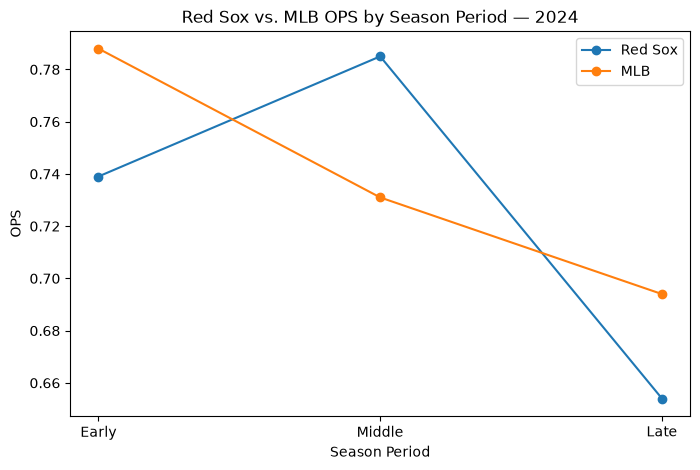

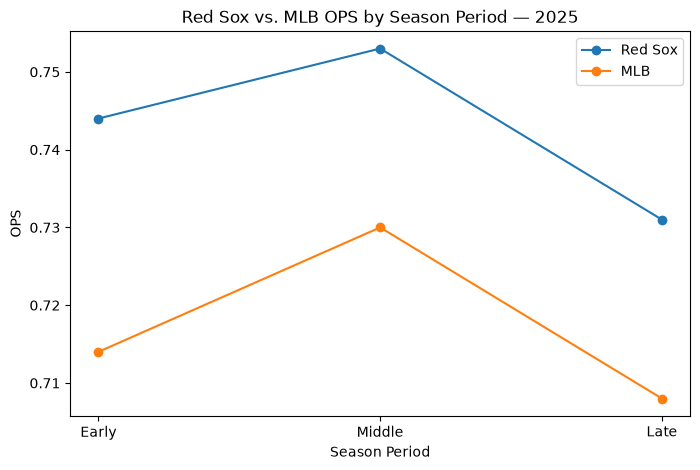

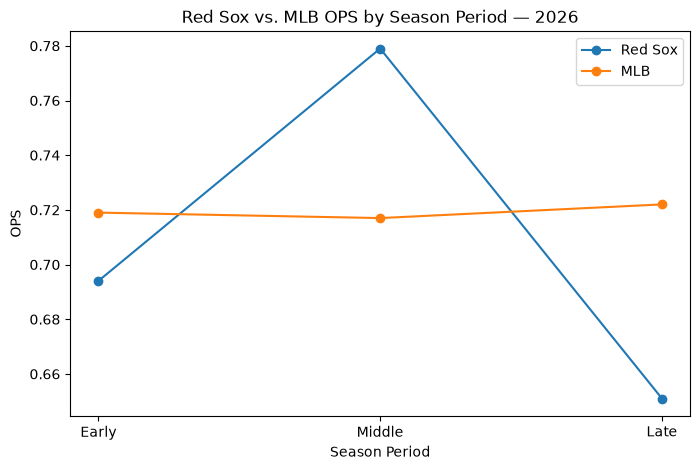

In [47]:
#Red Sox vs MLB OPS by season period in 2024, 2025, and 2026#
for year in [2024,2025,2026]:
    data_year = Offense_Comparison[Offense_Comparison["Year"] == year]
    plt.figure(figsize=(8,5))
    plt.plot(data_year["Period"],
             data_year["Red Sox OPS"],
             marker="o",
             label= "Red Sox")
    plt.plot(
    data_year["Period"],
    data_year["MLB OPS"],
    marker="o",
    label="MLB")
    plt.xlabel("Season Period")
    plt.ylabel("OPS")
    plt.title(f"Red Sox vs. MLB OPS by Season Period — {year}")
    plt.legend()
    plt.show()

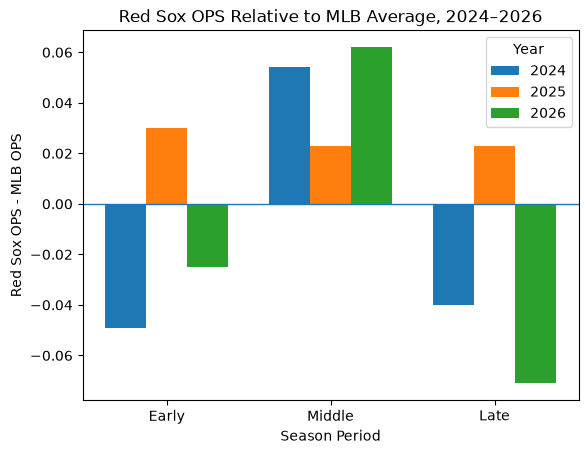

In [48]:
periods = ["Early", "Middle", "Late"]
years = [2024, 2025, 2026]
x = np.arange(len(periods))
width = 0.25
for i, year in enumerate(years):
    data_year = Offense_Comparison[
        Offense_Comparison["Year"] == year
    ]

    data_year = data_year.set_index("Period").loc[periods]

    plt.bar(
        x + (i - 1) * width,
        data_year["OPS_Difference"],
        width,
        label=str(year)
    )

plt.axhline(0, linewidth=1)
plt.xticks(x, periods)
plt.xlabel("Season Period")
plt.ylabel("Red Sox OPS - MLB OPS")
plt.title("Red Sox OPS Relative to MLB Average, 2024–2026")
plt.legend(title="Year")
plt.show()

### Results

The Red Sox offense performed above the MLB average during the Middle period in 2024, 2025, and 2026. In each of the three seasons, Boston's largest positive difference from the MLB average occurred during July and August. This suggests that Boston's midseason offensive improvement was more pronounced than the league-wide seasonal pattern.

There was more consistency across the three periods in 2025 than in either 2024 or 2026. The 2026 season showed the largest variation in Boston's offensive performance, with particularly low results during the Early and Late periods. In contrast, the Red Sox produced a .780 OPS during July and August, approximately 8% higher than the MLB OPS over the same period.

The statistics used in this analysis are not adjusted for park effects. Because Fenway Park is generally considered a hitter-friendly ballpark, Boston's raw offensive statistics may somewhat overstate its performance relative to a neutral offensive environment. However, the Middle period still stands out within this analysis because Boston's largest positive difference from the MLB average occurred during July and August in all three seasons.

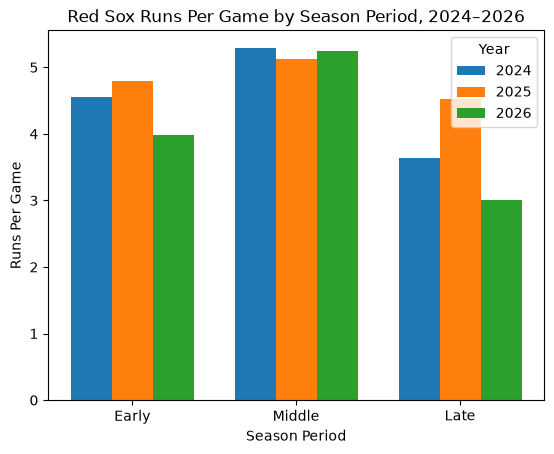

In [49]:
#Runs per game by season period for BOS, 2024-2026#
periods = ["Early", "Middle", "Late"]
years = [2024, 2025, 2026]

x = np.arange(len(periods))
width = 0.25

for i, year in enumerate(years):
    data_year = RedSox_Offense_2024_2026[
        RedSox_Offense_2024_2026["Year"] == year
    ]

    data_year = data_year.set_index("Period").loc[periods]

    plt.bar(
        x + (i - 1) * width,
        data_year["Runs Per Game"],
        width,
        label=str(year)
    )

plt.xticks(x, periods)
plt.xlabel("Season Period")
plt.ylabel("Runs Per Game")
plt.title("Red Sox Runs Per Game by Season Period, 2024–2026")
plt.legend(title="Year")
plt.show()

In [50]:
Wild_Card={"G":2, "AB":60, "R":2, "H":7, "2B":2, "3B":0, "HR":2,"BB":3}
Wild_Card_AVG_raw=Wild_Card["H"]/Wild_Card["AB"]
Wild_Card_OBP_raw=(Wild_Card["H"] + Wild_Card["BB"]) / (Wild_Card["AB"] + Wild_Card["BB"])
Wild_Card_2B=Wild_Card["2B"]
Wild_Card_HR=Wild_Card["HR"]
Wild_Card_1B=3
Wild_Card_TB=Wild_Card_1B+2*(Wild_Card_2B)+4*(Wild_Card_HR)
Wild_Card_SLG_raw=Wild_Card_TB/Wild_Card["AB"]
Wild_Card_OPS_raw=Wild_Card_OBP_raw+Wild_Card_SLG_raw
Wild_Card_AVG=round(Wild_Card_AVG_raw, 3)
Wild_Card_OBP=round(Wild_Card_OBP_raw, 3)
Wild_Card_SLG=round(Wild_Card_SLG_raw, 3)
Wild_Card_OPS=round(Wild_Card_OPS_raw, 3)
Runspergame_WC=Wild_Card["R"]/Wild_Card["G"]

print(f"AVG: {Wild_Card_AVG}")
print(f"OBP: {Wild_Card_OBP}")
print(f"SLG: {Wild_Card_SLG}")
print(f"OPS: {Wild_Card_OPS}")
print(f"Runs per game: {Runspergame_WC}")

AVG: 0.117
OBP: 0.159
SLG: 0.25
OPS: 0.409
Runs per game: 1.0


## Wild Card Series Case Study

In [51]:
RedSox_2026_Case_Study = RedSox_Offense_2024_2026[
    RedSox_Offense_2024_2026["Year"] == 2026].copy()
Wild_Card_Row = {
    "Year": 2026,
    "Period": "Wild Card Series",
    "Runs Per Game": 1.00,
    "AVG": 0.117,
    "OBP": 0.159,
    "SLG": 0.250,
    "OPS": 0.409
}
RedSox_2026_Case_Study.loc[
    len(RedSox_2026_Case_Study)
] = Wild_Card_Row
RedSox_2026_Case_Study

,Year,Period,Runs Per Game,AVG,OBP,SLG,OPS
6,2026,Early,3.99,0.243,0.310,0.384,0.694
7,2026,Middle,5.24,0.260,0.343,0.437,0.779
8,2026,Late,3.00,0.219,0.295,0.356,0.651
3,2026,Wild Card Series,1.00,0.117,0.159,0.250,0.409


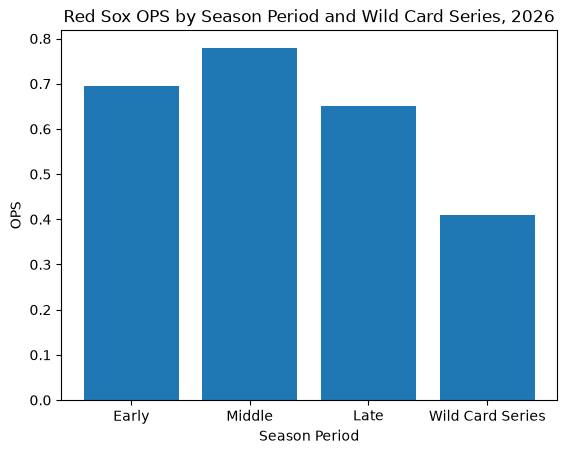

In [52]:
plt.bar(
    RedSox_2026_Case_Study["Period"],
    RedSox_2026_Case_Study["OPS"])
plt.xlabel("Season Period")
plt.ylabel("OPS")
plt.title("Red Sox OPS by Season Period and Wild Card Series, 2026")
plt.show()

### Results

The 2026 Wild Card Series provides an illustrative example of the offensive decline that followed Boston's strong Middle period. After producing a .780 OPS during July and August, the Red Sox fell to a .651 OPS during the Late period and recorded a .409 OPS in the Wild Card Series.

The Wild Card Series should be interpreted cautiously because it represents only a two-game sample against strong postseason competition. It is therefore not evidence of a broader trend on its own. Instead, it provides additional context for the larger 2026 pattern: Boston's offense improved substantially during July and August before declining late in the regular season and remaining low during the Wild Card Series.

## Limitations

- This analysis covers only three seasons (2024–2026). While this is enough to identify a consistent pattern across the seasons analyzed, it is not enough to determine whether the pattern represents a long-term tendency for the Red Sox.
- The Early, Middle, and Late periods contain different numbers of games, which should be considered when comparing the periods.
- The MLB comparison uses league-wide averages. While the analysis shows that the Red Sox's seasonal fluctuations were more pronounced than MLB's overall fluctuations, it does not determine how unusual Boston's pattern was compared with each individual MLB team.
- The offensive statistics used in this analysis are not park-adjusted, meaning the analysis does not control for Fenway Park's offensive environment.
- The 2026 Wild Card Series consisted of only two games and is therefore used only as an illustrative case study rather than evidence of a broader trend.

## Conclusion

The Red Sox offense performed better in July and August than it did at the beginning and end of the season in 2024, 2025, and 2026. The Middle period had the highest runs per game and OPS in all three seasons. Across the three-year sample, Boston averaged 5.22 runs per game with a .773 OPS during the Middle period, compared with 4.44 runs per game and a .726 OPS during the Early period and 3.72 runs per game with a .679 OPS during the Late period.

Boston's OPS was also further above the MLB average during July and August than during the Early or Late periods in each of the three seasons. This indicates that the midseason improvement was more pronounced for Boston than the league-wide seasonal pattern. The 2026 season provides the most pronounced example within the sample, with Boston improving from a .694 OPS early in the season to .780 during July and August before falling to .651 late in the season. The subsequent .409 OPS in the two-game Wild Card Series provides additional context for that late-season decline.

Overall, the results show a consistent pattern across the three seasons analyzed: Boston's offense performed best during July and August. However, the three-year sample does not establish that this is a long-term tendency for the Red Sox.